In [1]:
%load_ext autoreload
%autoreload 2

```{toctree}
:maxdepth: 4
:caption: Contents:

# Stationary case: walkthrough

```{warning}
The templates for the swan runs are planned to be updated in the near future to provide more flexibility to users who want to run cases under tailor-made conditions. The current templates assumes runs to be made under:

- Nautical conventions for wave direction
- Spherical coordinates
- Two-dimensional domains
- Specific numerics and physics (user is refered to the template files for details)
```

## Imports

In [3]:
import matplotlib.pyplot as plt
from oceanicospy.plots import *

In [4]:
from oceanicospy.models.swanpy import Initializer
from oceanicospy.models.swanpy.preprocess import GridMaker, BathyMaker, WindForcing,\
                                                 BottomFrictionProcessor, BoundaryConditions
from oceanicospy.models.swanpy.execution import CaseRunner
from oceanicospy.models.swanpy.postprocess import SwanOutputReader

## Workflow overview

This notebook walks through a complete SWAN **stationary** modelling workflow using the `swanpy` subpackage inside `oceanicospy`. The example is based on a stationary case for the San Andres island in Colombia.

```{warning}
The workflow assumes that input data (bathymetry `.bot`, friction `.fric` and output points `.csv`) are already placed in the appropriate `input/domain_0X/` folder inside the case directory.
```

## Case configuration

Three main parameters are required to set up a SWAN case:

| Parameter | Description |
|---|---|
| `path_case` | Root directory that will hold `input/`, `run/`, `output/`, `pros/` |
| `dict_ini_data` | Metadata dictionary consumed by the `Initializer` class for the case|
| `ini_date` / `end_date` | Simulation window in datetime format |


The initialization metadata dictionary (`dict_ini_data`) is a key component of the workflow, as it contains all the necessary information to retrieve and process input data (e.g., ERA5 files). This dictionary is expetected to have the following keys:

- ``name``: A string identifier for the case (e.g., "Stationary case for San Andrés").
- ``case_number`` (optional): An integer to differentiate between multiple cases (e.g., 1, 2, 3).
- ``case_description``: A brief description of the case (e.g., "Stationary", "Non-stationary").
- ``stat_id``: An integer indicating the type of run (0 for non-stationary, 1 for stationary). 
- ``number_of_domains``: total number of domains in the case (e.g., 1, 2, 3).
- ``parent_domains``: a dictionary specifying the parent domain for each nested domain (e.g., {"domain_02": "domain_01", "domain_03": "domain_02"}). If there are no nested domains, this can be set to None or an empty dictionary.

 The expected structure of this dictionary is detailed in the `Initializer` documentation.

In [36]:
path_case = '../../data/model_runs/stationary_swan/'

dict_ini_data = dict(
    name            = 'Stationary case',
    case_number     = 1,
    case_description= 'Example',
    stat_id         = 1,
    number_domains  = 1
)

```{hint}
`stat_id` convention in the `dict_ini_data` dictionary:
- `stat_id = 0` → **non-stationary** run  
- `stat_id = 1` → **stationary** run  ← _used in this notebook_
```

## Initialization

`Initializer` class creates the project directory tree and writes the baseline SWAN configuration file (`run.swn`) from a template. The tree has a structure like the following, where `domain_01` is the main domain (and only domain in this case):

```
path_case/
├── input/
│   └── domain_01/          ← place bathymetry and bottom friction files here if you have them locally
├── pros/
├── run/
│   └── domain_01/
│       └── run.swn         ← generated from template
└── output/
    └── domain_01/
```



All of this code is expected to be in a python file inside the `pros/` folder so `pros/` is the working directory when running the script and it should be already created before calling `Initializer`. The folder `input/domain_0X/` should also be created and populated with the necessary input files (bottom friction and bathymetry `.bot` file) before running the script.

```{note}

In [37]:
case = Initializer(
    root_path    = path_case,
    dict_ini_data= dict_ini_data,
)

case.create_folders()    # creates all project folders (data/, output/, etc.)
case.replace_ini_data()     # writes run.swn from the STAT template

*** Initializing SWAN model ***


	*** Creating project folder structure ***


	*** Copying base SWAN configuration file into run folder ***



## Generating the grid

`GridMaker` is a class inside `swanpy` that populates the `CGRID` and `INPGRID` sections of configuration file `run.swn`. 

One method is available to obtain the grid parameters:

| Method | When to use |
|---|---|
| `params_from_bathy()` | Derive extent and resolution automatically from the `.bot` bathymetry file |

```{note}

    If the params_from_bathy() method is used, the grid parameters will be automatically derived from the `.bot` bathymetry file. In this case, the user must ensure that the bathymetry file is correctly formatted and placed in the appropriate `input/domain_0X/` folder before running the script.
```

When the user provides the grid parameters and they are not inferred from the bathymetry file, the following keys are expected in the `grid_info` dictionary at the moment of calling the `GridMaker` class:
- `lon_ll_corner`: longitude of the lower-left corner of the grid
- `lat_ll_corner`: latitude of the lower-left corner of the grid
- `x_extent`: total extent of the grid in the x-direction (longitude)
- `y_extent`: total extent of the grid in the y-direction (latitude)
- `nx` : number of grid cells in the x-direction
- `ny`: number of grid cells in the y-direction


In [38]:
DOMAIN_ID = 1   # domain identifier (1-indexed)

case_grid = GridMaker(
    init         = case,
    domain_number= DOMAIN_ID,
    grid_info    = {'lon_ll_corner': 278.2265167, 
                    'lat_ll_corner': 12.4413166, 
                    'x_extent': 0.13185, 
                    'y_extent': 0.1908, 
                    'nx': 293,
                    'ny': 424},
)

# Option – derive grid parameters from the bathymetry file
# dict_grid = case_grid.params_from_bathy()

print(f'The grid info dictionary for domain {DOMAIN_ID} is: {case_grid.grid_info}')
case_grid.fill_grid_section()


*** Initializing gridmaker for domain 1 ***

The grid info dictionary for domain 1 is: {'lon_ll_corner': 278.2265167, 'lat_ll_corner': 12.4413166, 'x_extent': 0.13185, 'y_extent': 0.1908, 'nx': 293, 'ny': 424}

 	*** Adding/Editing grid information for domain 1 in configuration file ***



## Setting up the bathymetry

`BathyMaker` class fills the `BOTTOM` section of `run.swn`. There is one method to set up the bathymetry file for the model:

| Method | When to use |
|---|---|
| `use_ascii_file_from_user` | when a pre-processed `.bot` file already exists in `input/domain_0X/`. This method implies the use of a dictionary with bathymetry metadata. |


```{note}

    If the `use_ascii_file_from_user()` method is used, make sure that the pre-processed `.bot` file is correctly formatted and placed in the appropriate `input/domain_0X/` folder before running the script. This method will link or copy the existing `.bot` file to the run directory and update the bathymetry information in the configuration metadata, but it does not perform any processing on the file itself.
```

The bathymaker class expects a dictionary with bathymetry metadata to be provided at initialization. The expected keys in this dictionary are:

- `lon_ll_corner_bot`: longitude of the lower-left corner of the bathymetry grid
- `lat_ll_corner_bot`: latitude of the lower-left corner of the bathymetry grid
- `nx_bot`: number of grid cells in the x-direction for the bathymetry grid
- `ny_bot`: number of grid cells in the y-direction for the bathymetry grid
- `dx_bot`: grid cell size in the x-direction (longitude) for the bathymetry grid
- `dy_bot`: grid cell size in the y-direction (latitude) for the bathymetry grid

In [ ]:
case_bathy = BathyMaker(
    init         = case,
    domain_number= DOMAIN_ID,
    bathy_info   = {'lon_ll_corner_bot': 278.2265167, 'lat_ll_corner_bot': 12.4413166,
                    'nx_bot': 293, 'ny_bot': 424, 
                    'dx_bot': 0.00045, 'dy_bot': 0.00045},     
)

case_bathy.use_ascii_file_from_user()

print(f'The bathymetry info dictionary for domain {DOMAIN_ID} is: {case_bathy.bathy_info}')
case_bathy.fill_bathy_section()

```{hint}
If you already have a ready-to-use `.bot` file in `input/domain_01/`, call `case_bathy.use_ascii_file_from_user()` instead of `convert_xyz2asc` and pass the metadata dict as `bathy_info=` at construction time. 
```

**DEFINING A WARNING/NOTE FOR THE SYMLINK OPTION**

## Defining bottom friction information

`BottomFrictionProcessor` is a class inside `swanpy` that fills the `FRICTION` section of `run.swn` with the appropriate parameters for bottom friction.
Similarly to the bathymetry, there is one method available to set up the bottom friction file for the model based on existing information in the `input/domain_0X/` folder:

| Method | When to use |
|---|---|
| `use_ascii_file_from_user` | when a pre-processed `.fric` file already exists in `input/domain_0X/`. This method implies the use of a dictionary with bottom friction metadata. |

The expected keys in the bottom friction metadata dictionary are at the moment to initialize the `BottomFrictionProcessor` class are:
- `lon_ll_corner_fric`: longitude of the lower-left corner of the bottom friction grid
- `lat_ll_corner_fric`: latitude of the lower-left corner of the bottom friction grid
- `nx_fric`: number of grid cells in the x-direction for the bottom friction grid
- `ny_fric`: number of grid cells in the y-direction for the bottom friction grid
- `dx_fric`: grid cell size in the x-direction (longitude) for the bottom friction grid
- `dy_fric`: grid cell size in the y-direction (latitude) for the bottom friction grid

In [ ]:
case_bottom_friction = BottomFrictionProcessor(
    init         = case,
    domain_number= DOMAIN_ID,
    bottom_fric_info    = 
        {'lon_ll_corner_fric': 278.2265167, 'lat_ll_corner_fric': 12.4413166,
         'nx_fric': 293, 'ny_fric': 424,
         'dx_fric': 0.00045, 'dy_fric': 0.00045}
    )  # using grid info to fill friction section


case_bottom_friction.use_ascii_file_from_user()
print(f'The bottom friction info dictionary for domain {DOMAIN_ID} is: {case_bottom_friction.bottom_fric_info}')
case_bottom_friction.fill_friction_section()

## Defining wind forcing (constant)

`WindForcing` handles the retrieval of wind data, it converts it to the required format, and writes the `WIND` section of `run.swn`. For this scenario the data is not downloaded from any external source and it is explicitly provided as constant using the method `use_constant_wind()`. This method requieres the wind speed (in m/s) and direction (in degrees following the nautical convention, where 0° is North, 90° is East, etc.) to be provided as arguments. 

In [ ]:
case_winds = WindForcing(
    init         = case,
    domain_number= DOMAIN_ID,
)

case_winds.use_constant_wind(wind_speed=6.02, wind_dir=90)

print(f'The wind info dictionary for domain {DOMAIN_ID} is: {case_winds.dict_info}')

case_winds.fill_wind_section()

## Defining boundary conditions

`BoundaryConditions` writes the `BOUNDARY` section of `run.swn`. For this stationary case, the boundary conditions are defined through the sides of the domains so that informations has to be provided as a dictionary called ``bound_info`` at construction time. This dictionary is expected to have the following keys:

- `bound_type`: A string with the type of boundary condition ("side" or "segment" are supported)
- `variable_bound`: A boolean indicating whether the boundary condition is time-variable (True) or constant (False)

In [ ]:
case_boundary = BoundaryConditions(
    init        = case,
    domain_number= DOMAIN_ID,
    bound_info   = {"bound_type": "side","variable_bound": False})

Once the class is initialized, the method `create_boundary_line()` can be used to define the boundary conditions along the sides of the domain. This method requires a list of sides (e.g., ["N", "S", "E", "W"]) and a dictionary with wave parameters (e.g., {'hs': 1.5, 'tp': 8, 'dir': 90, 'spr': 2}) to be provided as arguments. The wave parameters include significant wave height (`hs`), peak period (`tp`), and wave direction (`dir`) and wave spread (`spr`). 

```{hint}
The wave direction (`dir`) in the boundary conditions is also defined following the nautical convention.
```

In [ ]:
case_boundary.create_boundary_line(list_sides=["E"],wave_params={'hs': 1.7, 'tp': 9, 'dir': 90 , 'spr':2})
case_boundary.fill_boundaries_section()

## Computation and run configuration

Finally, after all the input data is set up, the `CaseRunner` class handles the final steps to finish the configuration of the case and prepare it for running. The main methods of this class are:

* `define_output_from_file()` – reads a CSV of output point coordinates and writes a `.loc` file.
* `fill_computation_section()` – writes the `COMPUTE` command (stationary or non-stationary).
* `fill_slurm_file()` – (HPC only) generates a SLURM launcher script.


`CaseRunner` expects a dictionary of computation parameters (`dict_comp_data`) that contains all the necessary information to write the `COMPUTE` section of `run.swn`. All the supported keys are listed below. 

- `stat_comp`: 1 for stationary, 0 for non-stationary
- `comp_dates`: list of datetime objects for computation dates
- `init_intermediate`: boolean to insert INIT commands between snapshots



For a stationary run, the following keys are expected in this dictionary:

In [ ]:
comp_data_stat = dict(
    stat_comp        = 1,               # 1 → stationary
)

Finally the CaseRunner is instantiated with the initialized case and the computation parameters. Then the `define_output_from_file()` and `fill_computation_section()` methods are called to write the output definition and the COMPUTE command in run.swn, respectively. The case is now ready to be run with SWAN.

In [ ]:
case_run = CaseRunner(
    init         = case,
    domain_number= DOMAIN_ID,
    dict_comp_data= comp_data_stat
)

# define point output locations from a CSV with X, Y columns
case_run.define_output_from_file(filename='output_points.csv')

# Write the COMPUTE command and clean up any remaining template placeholders
case_run.fill_computation_section()

# (Optional) generate SLURM launcher for HPC submission
# case_run.fill_slurm_file()

All the information ready to be used for the stationary case is now set up and it can be found in the `run/domain_01` folder. The next step is to run the case using the swan executable on the HPC or locally, depending on the setup. 

## Reading the output

After running the case, the output files will be generated in the `output/domain_01/` folder, and they can be post-processed and visualized as needed. For this step, we can use the `SwanOutputReader` class in `swanpy` which provides methods to read and extract information from the SWAN output files, such as wave spectra, time series at specific locations, and spatial maps of wave parameters. The reader can handle both stationary and non-stationary outputs, allowing for flexible post-processing and analysis of the results.

### Point output

The output points defined in the `.loc` file can be read using the `read_point_output()` method of the `SwanOutputReader` class. This method allows to extract time series of wave parameters at specific locations defined in the output points file. If the run is stationary, the output will consist of a single snapshot of wave parameters at each output point, which can be easily extracted and visualized using this method.

Two parameters are expected to be provided as arguments when calling the `read_point_output()` method:
- `output_dir`: the directory where the output files are located (e.g., `output/domain_01/`)
- `file_name`: the name of the output file to read (e.g., `PointSWAN.out`)

In [5]:
out_reader = SwanOutputReader()

point_df = out_reader.read_point_output(output_dir = '../../data/model_runs/stationary_swan/output/domain_01/',
                             filename = 'PointSWAN.out')

point_df

,Xp,Yp,Depth,X-Windv,Y-Windv,Hsig,TPsmoo,Tm01,Tm02,Dir
point,,,,,,,,,,
1,278.293,12.5172,10.8147,-6.02,0.0,1.314,8.8572,7.4214,6.9301,101.07


### Wave spectra

The wave spectra output can be read using the `read_spectra_output()` method of the `SwanOutputReader` class. The method requires similar parameters as the point output reader, such as `output_dir` and `file_name`, to locate and read the appropriate output files. The spectra will usually have the dimensions of `(time,site,frequency,direction)` or `(time,lon,lat,frequency,direction)` depending on the as_site parameter used in the `read_spectra_output()` method call.
```

In [6]:
wave_spectra = out_reader.read_spectral_output(output_dir = '../../data/model_runs/stationary_swan/output/domain_01/',
                                          filename = 'SpecSWAN.out')

In [7]:
wave_spectra

<xarray.Dataset> Size: 21kB
Dimensions:  (time: 1, site: 1, freq: 35, dir: 72)
Coordinates:
  * time     (time) datetime64[ns] 8B 2026-04-21T08:39:00
  * site     (site) <U8 32B 'SpecSWAN'
  * freq     (freq) float64 280B 0.04 0.044 0.0483 0.0531 ... 0.8275 0.9097 1.0
  * dir      (dir) float64 576B 2.5 7.5 12.5 17.5 ... 342.5 347.5 352.5 357.5
Data variables:
    efth     (time, site, freq, dir) float64 20kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    lat      (site) float64 8B 12.52
    lon      (site) float64 8B 278.3

In [ ]:
wave_spectra.coords

In [25]:
# Closing the wave spectra to make a complete polar plot of the directional distribution

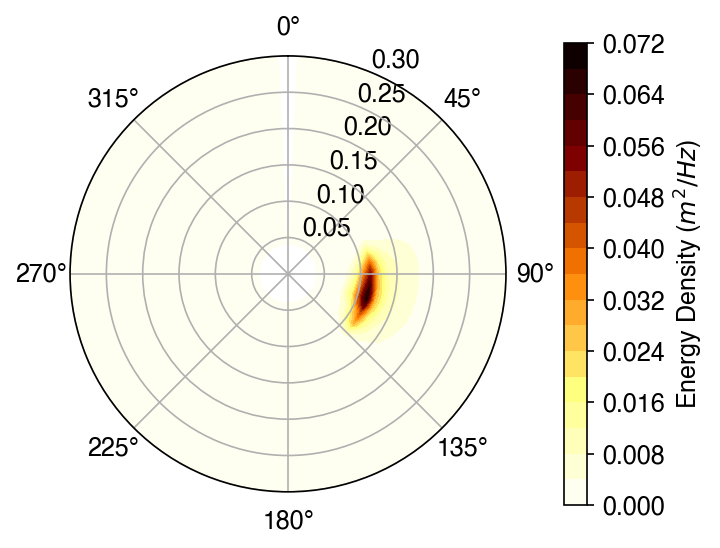

In [32]:
theta,r = np.meshgrid(wave_spectra.dir.values, wave_spectra.freq.values)
fig,ax = plt.subplots(figsize=(5,4),subplot_kw={'projection': 'polar'})
cf = ax.contourf(np.deg2rad(theta), r, wave_spectra['efth'][0,0,:,:], levels=20,cmap='afmhot_r')
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set(ylim=(0,0.3))
plt.colorbar(cf, label='Energy Density ($m^2/Hz$)',pad=0.1)
plt.show()


In [12]:
wave_spectra['efth'][0,0,:,:]

<xarray.DataArray 'efth' (freq: 35, dir: 72)> Size: 20kB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(35, 72))
Coordinates:
    time     datetime64[ns] 8B 2026-04-21T08:39:00
    site     <U8 32B 'SpecSWAN'
  * freq     (freq) float64 280B 0.04 0.044 0.0483 0.0531 ... 0.8275 0.9097 1.0
  * dir      (dir) float64 576B 2.5 7.5 12.5 17.5 ... 342.5 347.5 352.5 357.5
Attributes:
    standard_name:   sea_surface_wave_directional_variance_spectral_density
    units:           m2 s degree-1
    _units:          m^{2}.s.degree^{-1}
    _variable_name:  VaDens

### Spatial output

Finally, the spatial output files generated by SWAN can be read and processed using the `SwanOutputReader` class as well. The method `read_spatial_output()` can be used to extract spatial maps of wave parameters from the output files. Similar to the other output reading methods, this method requires the `output_dir` and `file_name` parameters to locate the appropriate output files for reading.

On top of that, the `read_spatial_output()` method can infer the spatial dimensions of the output data or use the `grid_info` parameter used in the grid definition to build the proper dimension in the xarray dataset.

In [39]:
wave_field_ds = out_reader.read_spatial_output(output_dir = '../../data/model_runs/stationary_swan/output/domain_01/',
                                                  filename = 'wave_field.mat',
                                                  grid_info = case_grid.grid_info)

FileNotFoundError: [Errno 2] No such file or directory: '../../data/model_runs/stationary_swan/output/domain_01/wave_field.mat'

In [40]:
wave_field_ds

NameError: name 'wave_field_ds' is not defined

A quick plot of the spatial ouput along with the output point is made to illustrate the results.

In [ ]:
fig,ax = plt.subplots(figsize=(3,4))
cf = ax.contourf(wave_field_ds.lon, wave_field_ds.lat, wave_field_ds["Hsig"], levels=20)
ax.plot(point_df['Xp'], point_df['Yp'], 'ro', label='Output point')
ax.set(xlabel='Longitude', ylabel='Latitude')
plt.colorbar(cf, label='Significant Wave Height (m)', fraction = 0.08)
plt.show()